# Evaluation Notebook - Multi-Agent Manipulation Detection

Notebook này đánh giá performance của hệ thống multi-agent trên 3 tasks:
1. **Task 1**: Manipulation Detection (Yes/No)
2. **Task 2**: Primary Manipulator Identification (Plaintiff/Defendant/None)
3. **Task 3**: Manipulation Techniques Classification (Multi-label)

## Metrics:
- Accuracy, Precision, Recall, F1-score
- Confusion Matrix
- Jaccard Score (cho multi-label)

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, jaccard_score
from sklearn.preprocessing import LabelEncoder, MultiLabelBinarizer

## 2. Load Data 

In [2]:
df_results = pd.read_csv('/kaggle/input/st1-stg2-p2/manipulation_results.csv')
df_test = pd.read_csv('/kaggle/input/data-clean2/test_split.csv') 

cot_can_them = ['Manipulative', 'Primary Manipulator', 'Manipulation Techniques'] 
df_test_subset = df_test[cot_can_them]

test = pd.concat([df_results, df_test_subset], axis=1)

print(test.head())

                                            Dialogue  \
0  Judge\r\nI understand, but my hypothetical ass...   
1  Judge:\nWell, but if -- why -- your voluntary ...   
2  Judge: Why did you go?\nPlaintiff: I had nothi...   
3  \nJudge:\nTell me what happened.\n\nPlaintiff ...   
4  Judge: Is your position— is there any daylight...   

                                           PLAINTIFF  \
0  The Plaintiff's statements suggest that they a...   
1  The Plaintiff's goal or motive behind their wo...   
2  The Plaintiff's statements suggest that their ...   
3  The Plaintiff, Nicole Yarboro, is seeking comp...   
4  The Plaintiff's statements suggest that they a...   

                                           DEFENDANT Manipulation_Present  \
0  The Defendant's lawyer is arguing that their c...                   No   
1  The Defendant's goal in reopening the voluntar...                   No   
2  The Defendant's statements suggest that their ...                  Yes   
3  The Defendant, 

## 3. Task 1: Manipulation Detection (Binary Classification)

Đánh giá khả năng phát hiện có/không có manipulation.

In [3]:
print("True label distribution:\n", test["Manipulative"].value_counts(dropna=False))
print("\nPredicted label distribution:\n", test["Manipulation_Present"].value_counts(dropna=False))

True label distribution:
 Manipulative
1    95
0    60
Name: count, dtype: int64

Predicted label distribution:
 Manipulation_Present
Yes    87
No     68
Name: count, dtype: int64


In [4]:
test["Manipulation_Present"] = test["Manipulation_Present"].map({'Yes': 1, 'No': 0})
# test["Manipulative"] = test["Manipulative"].map({'Yes': 1, 'No': 0})
targets = test["Manipulative"].astype(int).tolist()
manipulative_preds = test["Manipulation_Present"].astype(int).tolist()

In [5]:
accuracy = accuracy_score(targets, manipulative_preds)
precision = precision_score(targets, manipulative_preds, zero_division=0)
recall = recall_score(targets, manipulative_preds, zero_division=0)
f1 = f1_score(targets, manipulative_preds, average="binary", zero_division=0)
conf_matrix = confusion_matrix(targets, manipulative_preds)

print("="*50)
print("TASK 1: MANIPULATION DETECTION")
print("="*50)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"\nConfusion Matrix:")
print(f"                Predicted")
print(f"              No      Yes")
print(f"Actual No   {conf_matrix[0][0]:4d}    {conf_matrix[0][1]:4d}")
print(f"Actual Yes  {conf_matrix[1][0]:4d}    {conf_matrix[1][1]:4d}")

TASK 1: MANIPULATION DETECTION
Accuracy:  0.8323
Precision: 0.8966
Recall:    0.8211
F1 Score:  0.8571

Confusion Matrix:
                Predicted
              No      Yes
Actual No     51       9
Actual Yes    17      78


## 4. Task 2: Primary Manipulator Identification

Đánh giá khả năng xác định manipulator (Plaintiff/Defendant/None).

In [6]:
# Chuẩn hóa cả ground truth và prediction về cùng format
test["Primary_Manipulator"] = test["Primary_Manipulator"].fillna("None").str.strip()
test["Primary Manipulator"] = test["Primary Manipulator"].fillna("None").str.strip()

# Kiểm tra unique values
print("Ground Truth unique values:", test["Primary_Manipulator"].unique())
print("Predicted unique values:", test["Primary Manipulator"].unique())

# Encode labels
all_categories = list(set(
    test["Primary_Manipulator"].tolist() + test["Primary Manipulator"].tolist()
))
encoder = LabelEncoder()
encoder.fit(all_categories)

targets_encoded = encoder.transform(test["Primary_Manipulator"])
preds_encoded = encoder.transform(test["Primary Manipulator"])

label_mapping = dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))
print("\nLabel Encoding Mapping:", label_mapping)

Ground Truth unique values: ['None' 'Plaintiff' 'Defendant']
Predicted unique values: ['None' 'Plaintiff' 'Defendant']

Label Encoding Mapping: {'Defendant': 0, 'None': 1, 'Plaintiff': 2}


In [7]:
accuracy = accuracy_score(targets_encoded, preds_encoded)
precision = precision_score(targets_encoded, preds_encoded, average="weighted", zero_division=0)
recall = recall_score(targets_encoded, preds_encoded, average="weighted", zero_division=0)
f1 = f1_score(targets_encoded, preds_encoded, average="weighted", zero_division=0)
conf_matrix = confusion_matrix(targets_encoded, preds_encoded)

print("\n" + "="*50)
print("TASK 2: PRIMARY MANIPULATOR IDENTIFICATION")
print("="*50)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f} (weighted)")
print(f"Recall:    {recall:.4f} (weighted)")
print(f"F1 Score:  {f1:.4f} (weighted)")
print(f"\nConfusion Matrix:")
print(conf_matrix)
print(f"\nLabel mapping: {dict(zip(encoder.transform(encoder.classes_), encoder.classes_))}")


TASK 2: PRIMARY MANIPULATOR IDENTIFICATION
Accuracy:  0.6968
Precision: 0.7126 (weighted)
Recall:    0.6968 (weighted)
F1 Score:  0.7025 (weighted)

Confusion Matrix:
[[42  9  9]
 [ 9 51  8]
 [12  0 15]]

Label mapping: {0: 'Defendant', 1: 'None', 2: 'Plaintiff'}


## 4. Task 3: Techniques Manipulator Identification

Đánh giá khả năng xác định các kỹ thuật manipulator (11 kỹ thuật).

In [8]:
# Convert to string và xử lý
test["Manipulation Techniques"] = test["Manipulation Techniques"].fillna("None").astype(str)
test["Techniques_Used"] = test["Techniques_Used"].fillna("None").astype(str)

print("Sample Ground Truth techniques:")
print(test["Manipulation Techniques"].head(10))
print("\nSample Predicted techniques:")
print(test["Techniques_Used"].head(10))

# Parse comma-separated strings thành lists
def parse_techniques(x):
    if pd.isna(x) or x == "None" or x == "nan":
        return ["None"]
    # Split by comma, strip whitespace, lowercase
    return [t.strip().lower() for t in str(x).split(",") if t.strip()]

test["Manipulation Techniques"] = test["Manipulation Techniques"].apply(parse_techniques)
test["Techniques_Used"] = test["Techniques_Used"].apply(parse_techniques)

# Kiểm tra unique labels
unique_gt_labels = set(label for labels in test["Manipulation Techniques"] for label in labels)
unique_pred_labels = set(label for labels in test["Techniques_Used"] for label in labels)

print("\n" + "="*50)
print("Unique Labels in Ground Truth:", sorted(unique_gt_labels))
print("Unique Labels in Predictions:", sorted(unique_pred_labels))
print("Labels in Predictions but NOT in Ground Truth:", unique_pred_labels - unique_gt_labels)
print("Labels in Ground Truth but NOT in Predictions:", unique_gt_labels - unique_pred_labels)

# Multi-label binarization
mlb = MultiLabelBinarizer()
all_labels = list(unique_gt_labels | unique_pred_labels)
mlb.fit([all_labels])

y_true = mlb.transform(test["Manipulation Techniques"])
y_pred = mlb.transform(test["Techniques_Used"])

# Calculate metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
recall = recall_score(y_true, y_pred, average="macro", zero_division=0)
f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
jaccard = jaccard_score(y_true, y_pred, average="samples", zero_division=0)

print("\n" + "="*50)
print("TASK 3: MANIPULATION TECHNIQUES CLASSIFICATION")
print("="*50)
print(f"Accuracy:      {accuracy:.4f} (exact match)")
print(f"Precision:     {precision:.4f} (macro)")
print(f"Recall:        {recall:.4f} (macro)")
print(f"F1 Score:      {f1:.4f} (macro)")
print(f"Jaccard Score: {jaccard:.4f} (samples)")
print(f"\nTotal unique techniques: {len(mlb.classes_)}")
print(f"Techniques: {sorted(mlb.classes_)}")

Sample Ground Truth techniques:
0                                                 None
1                                                 None
2                             deflection, minimization
3    gaslighting, deflection, emotional appeal, pla...
4                                                 None
5                       deflection, playing the victim
6                                                 None
7    gaslighting, character attack, playing the victim
8                                                 None
9          gaslighting, deflection, playing the victim
Name: Manipulation Techniques, dtype: object

Sample Predicted techniques:
0                                                 None
1                                                 None
2                                     emotional appeal
3    playing the victim, gaslighting, deflection, m...
4                                                 None
5    playing the victim, evasion, deflection, minim...
6            

## 6. Final Summary

Tổng hợp tất cả metrics từ 3 tasks.

In [9]:
print("\n" + "="*60)
print(" "*15 + "FINAL EVALUATION SUMMARY")
print("="*60)
print("\nDataset Size:", len(test))
print("\n" + "-"*60)
print(f"{'Task':<45} {'Metric':<10} {'Score':<10}")
print("-"*60)

# Task 1
task1_acc = accuracy_score(targets, manipulative_preds)
task1_f1 = f1_score(targets, manipulative_preds, average="binary", zero_division=0)
print(f"{'1. Manipulation Detection (Binary)':<45} {'Accuracy':<10} {task1_acc:.4f}")
print(f"{'':<45} {'F1':<10} {task1_f1:.4f}")

# Task 2  
task2_acc = accuracy_score(targets_encoded, preds_encoded)
task2_f1 = f1_score(targets_encoded, preds_encoded, average="weighted", zero_division=0)
print(f"{'2. Primary Manipulator (3-class)':<45} {'Accuracy':<10} {task2_acc:.4f}")
print(f"{'':<45} {'F1 (wtd)':<10} {task2_f1:.4f}")

# Task 3
task3_acc = accuracy_score(y_true, y_pred)
task3_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
task3_jaccard = jaccard_score(y_true, y_pred, average="samples", zero_division=0)
print(f"{'3. Techniques Classification (Multi-label)':<45} {'Accuracy':<10} {task3_acc:.4f}")
print(f"{'':<45} {'F1 (macro)':<10} {task3_f1:.4f}")
print(f"{'':<45} {'Jaccard':<10} {task3_jaccard:.4f}")

print("="*60)
print("\nEvaluation completed!")


               FINAL EVALUATION SUMMARY

Dataset Size: 155

------------------------------------------------------------
Task                                          Metric     Score     
------------------------------------------------------------
1. Manipulation Detection (Binary)            Accuracy   0.8323
                                              F1         0.8571
2. Primary Manipulator (3-class)              Accuracy   0.6968
                                              F1 (wtd)   0.7025
3. Techniques Classification (Multi-label)    Accuracy   0.3484
                                              F1 (macro) 0.2218
                                              Jaccard    0.4200

Evaluation completed!


# Error Analysis

In [10]:
import pandas as pd
import numpy as np
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_fscore_support

In [11]:
# Load data
df = pd.read_csv('/kaggle/input/st1-stg2-p2/manipulation_results.csv')
df_test = pd.read_csv('/kaggle/input/data-clean2/test_split.csv')

# Merge
test = pd.concat([df, df_test[['Manipulative', 'Primary Manipulator', 'Manipulation Techniques']]], axis=1)

# Parse techniques
def parse_techniques(x):
    if pd.isna(x) or x == "None" or x == "nan":
        return []
    return [t.strip().lower() for t in str(x).split(",") if t.strip() and t.strip().lower() != "none"]

test["true_techniques"] = test["Manipulation Techniques"].apply(parse_techniques)
test["pred_techniques"] = test["Techniques_Used"].apply(parse_techniques)

# Convert manipulation to binary
test["Manipulation_Present_bin"] = test["Manipulation_Present"].map({'Yes': 1, 'No': 0})
test["Manipulative_bin"] = test["Manipulative"].astype(int)

# Standardize manipulator labels
test["Primary_Manipulator"] = test["Primary_Manipulator"].fillna("None").str.strip()
test["Primary Manipulator"] = test["Primary Manipulator"].fillna("None").str.strip()

In [12]:
# ============================================================================
# TASK 1: MANIPULATION DETECTION ERROR ANALYSIS
# ============================================================================
print("\n" + "="*100)
print("TASK 1: MANIPULATION DETECTION - ERROR ANALYSIS")
print("="*100)

# False Positives Analysis
fp_cases = test[(test["Manipulative_bin"] == 0) & (test["Manipulation_Present_bin"] == 1)]
print(f"\n### FALSE POSITIVES: {len(fp_cases)} cases (model said YES, but actually NO)")
print("\nSample False Positive cases:")
for idx, row in fp_cases.head(3).iterrows():
    print(f"\n--- Case {idx} ---")
    print(f"Dialogue snippet: {row['Dialogue'][:300]}...")
    print(f"Predicted Manipulator: {row['Primary_Manipulator']}")
    print(f"Predicted Techniques: {row['Techniques_Used']}")

# False Negatives Analysis
fn_cases = test[(test["Manipulative_bin"] == 1) & (test["Manipulation_Present_bin"] == 0)]
print(f"\n### FALSE NEGATIVES: {len(fn_cases)} cases (model said NO, but actually YES)")
print("\nSample False Negative cases:")
for idx, row in fn_cases.head(3).iterrows():
    print(f"\n--- Case {idx} ---")
    print(f"Dialogue snippet: {row['Dialogue'][:300]}...")
    print(f"True Manipulator: {row['Primary Manipulator']}")
    print(f"True Techniques: {row['Manipulation Techniques']}")

# Dialogue length analysis
test['dialogue_length'] = test['Dialogue'].str.split().str.len()
print("\n### DIALOGUE LENGTH IMPACT ON TASK 1:")
for length_range in [(0, 500), (500, 1000), (1000, 2000), (2000, 10000)]:
    subset = test[(test['dialogue_length'] >= length_range[0]) & (test['dialogue_length'] < length_range[1])]
    if len(subset) > 0:
        acc = (subset['Manipulative_bin'] == subset['Manipulation_Present_bin']).mean()
        print(f"  {length_range[0]:4d}-{length_range[1]:4d} words: {len(subset):3d} cases, Accuracy: {acc:.3f}")


TASK 1: MANIPULATION DETECTION - ERROR ANALYSIS

### FALSE POSITIVES: 9 cases (model said YES, but actually NO)

Sample False Positive cases:

--- Case 10 ---
Dialogue snippet: Judge: And Franklin, I think, is kind of our north star here at least as I've unpacked the case.
Defendant's Lawyer: Right. But -- but I think Franklin, you could either read it as being a case about significant interference based on the record, as I pointed out, or I think what this Court said is i...
Predicted Manipulator: Defendant
Predicted Techniques: persuasion, playing the victim, gaslighting, evasion, deflection, minimization, dismissal, guilt tripping, emotional appeal, framing the narrative, character attack

--- Case 11 ---
Dialogue snippet: Judge
And, Your Honor, again, it is a concern -- two responses. First, it is a concern that can be addressed directly.

Lawyer of Defendant
The reason why there's no evidence in this record about whether that kind of direct prohibition on TikTok, Incorporated, fr

In [13]:
# ============================================================================
# TASK 2: PRIMARY MANIPULATOR ERROR ANALYSIS
# ============================================================================
print("\n" + "="*100)
print("TASK 2: PRIMARY MANIPULATOR - DETAILED ERROR ANALYSIS")
print("="*100)

# Confusion analysis
manipulator_errors = defaultdict(lambda: defaultdict(int))
for idx, row in test.iterrows():
    true_manip = row['Primary Manipulator']
    pred_manip = row['Primary_Manipulator']
    
    if true_manip != pred_manip:
        manipulator_errors[true_manip][pred_manip] += 1

print("\n### CONFUSION BREAKDOWN:")
for true_label in ['Plaintiff', 'Defendant', 'None']:
    if true_label in manipulator_errors:
        print(f"\n{true_label} cases wrongly predicted as:")
        for pred_label, count in manipulator_errors[true_label].items():
            total = len(test[test['Primary Manipulator'] == true_label])
            pct = (count / total * 100) if total > 0 else 0
            print(f"  → {pred_label}: {count}/{total} ({pct:.1f}%)")

# Plaintiff misclassification analysis (biggest problem)
print("\n### DEEP DIVE: PLAINTIFF MISCLASSIFICATIONS (Biggest Problem!)")
plaintiff_errors = test[(test['Primary Manipulator'] == 'Plaintiff') & 
                       (test['Primary_Manipulator'] != 'Plaintiff')]
print(f"\nTotal Plaintiff cases: {len(test[test['Primary Manipulator'] == 'Plaintiff'])}")
print(f"Correctly identified: {len(test[(test['Primary Manipulator'] == 'Plaintiff') & (test['Primary_Manipulator'] == 'Plaintiff')])}")
print(f"Misclassified: {len(plaintiff_errors)}")

print("\nPattern analysis of Plaintiff errors:")
for idx, row in plaintiff_errors.head(5).iterrows():
    print(f"\n--- Plaintiff Error Case {idx} ---")
    print(f"Predicted as: {row['Primary_Manipulator']}")
    print(f"True techniques: {row['Manipulation Techniques']}")
    print(f"Predicted techniques: {row['Techniques_Used']}")
    print(f"Dialogue snippet: {row['Dialogue'][:250]}...")

# Check if there's a pattern: does Intent help?
if 'PLAINTIFF' in test.columns and 'DEFENDANT' in test.columns:
    print("\n### INTENT QUALITY ANALYSIS:")
    for idx, row in plaintiff_errors.head(3).iterrows():
        print(f"\n--- Case {idx} ---")
        print(f"Plaintiff Intent: {row['PLAINTIFF'][:150]}...")
        print(f"Defendant Intent: {row['DEFENDANT'][:150]}...")


TASK 2: PRIMARY MANIPULATOR - DETAILED ERROR ANALYSIS

### CONFUSION BREAKDOWN:

Plaintiff cases wrongly predicted as:
  → None: 8/32 (25.0%)
  → Defendant: 9/32 (28.1%)

Defendant cases wrongly predicted as:
  → Plaintiff: 12/63 (19.0%)
  → None: 9/63 (14.3%)

None cases wrongly predicted as:
  → Defendant: 9/60 (15.0%)

### DEEP DIVE: PLAINTIFF MISCLASSIFICATIONS (Biggest Problem!)

Total Plaintiff cases: 32
Correctly identified: 15
Misclassified: 17

Pattern analysis of Plaintiff errors:

--- Plaintiff Error Case 16 ---
Predicted as: None
True techniques: persuasion, framing the narrative, minimization, emotional appeal, playing the victim
Predicted techniques: nan
Dialogue snippet: Judge: Okay, Mr. Plav, you are suing Mrs. Cernic for $623.41, that you say she owes you for different jobs that you did for her husband. According to you, her husband never paid. Now, your husband is deceased, correct?

Plaintiff: Yeah.

Judge: How l...

--- Plaintiff Error Case 19 ---
Predicted as: Non

In [14]:
# ============================================================================
# TASK 3: TECHNIQUE CLASSIFICATION ERROR ANALYSIS
# ============================================================================
print("\n" + "="*100)
print("TASK 3: TECHNIQUE CLASSIFICATION - COMPREHENSIVE ERROR ANALYSIS")
print("="*100)

all_techniques = [
    'gaslighting', 'guilt tripping', 'emotional appeal',
    'character attack', 'deflection', 'framing the narrative',
    'minimization', 'evasion', 'dismissal',
    'playing the victim', 'persuasion'
]

# Per-technique metrics
print("\n### PER-TECHNIQUE PERFORMANCE:")
print(f"{'Technique':<25} {'Support':<10} {'Precision':<12} {'Recall':<12} {'F1':<12} {'FP':<8} {'FN':<8}")
print("-" * 100)

tech_metrics = []
for tech in all_techniques:
    y_true = test["true_techniques"].apply(lambda x: tech in x)
    y_pred = test["pred_techniques"].apply(lambda x: tech in x)
    
    tp = sum(y_true & y_pred)
    fp = sum(~y_true & y_pred)
    fn = sum(y_true & ~y_pred)
    
    support = sum(y_true)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    tech_metrics.append({
        'technique': tech,
        'support': support,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'fp': fp,
        'fn': fn
    })
    
    print(f"{tech:<25} {support:<10} {precision:<12.3f} {recall:<12.3f} {f1:<12.3f} {fp:<8} {fn:<8}")

# Sort by performance
tech_df = pd.DataFrame(tech_metrics)

print("\n### TOP 5 WORST PERFORMING TECHNIQUES (by F1):")
worst = tech_df.nsmallest(5, 'f1')
for idx, row in worst.iterrows():
    print(f"\n{row['technique'].upper()}:")
    print(f"  F1: {row['f1']:.3f} | Precision: {row['precision']:.3f} | Recall: {row['recall']:.3f}")
    print(f"  Support: {row['support']} | FP: {row['fp']} | FN: {row['fn']}")
    
    # Show why it's failing
    if row['precision'] < 0.3:
        print(f"  ⚠️  LOW PRECISION → Model is over-predicting this technique")
    if row['recall'] < 0.3:
        print(f"  ⚠️  LOW RECALL → Model is missing this technique")

print("\n### TOP 5 BEST PERFORMING TECHNIQUES:")
best = tech_df.nlargest(5, 'f1')
for idx, row in best.iterrows():
    print(f"  {row['technique']:<25} F1: {row['f1']:.3f}")

# Confusion between techniques
print("\n### TECHNIQUE CONFUSION ANALYSIS:")
print("(When model predicts technique A but it's actually technique B)")

confusion_pairs = defaultdict(int)
for idx, row in test.iterrows():
    true_set = set(row['true_techniques'])
    pred_set = set(row['pred_techniques'])
    
    # For single-label mismatches
    if len(true_set) == 1 and len(pred_set) == 1 and true_set != pred_set:
        true_tech = list(true_set)[0]
        pred_tech = list(pred_set)[0]
        confusion_pairs[(pred_tech, true_tech)] += 1

if confusion_pairs:
    print("\nTop 10 confusion pairs:")
    for (pred, true), count in sorted(confusion_pairs.items(), key=lambda x: x[1], reverse=True)[:10]:
        print(f"  Predicted '{pred}' when actually '{true}': {count} times")

# Multi-label analysis
print("\n### MULTI-LABEL COMPLEXITY ANALYSIS:")
test['num_true_techniques'] = test['true_techniques'].apply(len)
test['num_pred_techniques'] = test['pred_techniques'].apply(len)

print("\nDistribution of number of techniques:")
print(test['num_true_techniques'].value_counts().sort_index())

print("\nPerformance by number of true techniques:")
for n in range(0, 6):
    subset = test[test['num_true_techniques'] == n]
    if len(subset) > 0:
        # Calculate Jaccard for this subset
        jaccards = []
        for idx, row in subset.iterrows():
            true_set = set(row['true_techniques'])
            pred_set = set(row['pred_techniques'])
            if len(true_set | pred_set) > 0:
                jaccard = len(true_set & pred_set) / len(true_set | pred_set)
            else:
                jaccard = 1.0
            jaccards.append(jaccard)
        
        avg_jaccard = np.mean(jaccards)
        print(f"  {n} techniques: {len(subset):3d} cases, Avg Jaccard: {avg_jaccard:.3f}")

# Over/Under prediction analysis
print("\n### OVER/UNDER PREDICTION ANALYSIS:")
over_pred = test[test['num_pred_techniques'] > test['num_true_techniques']]
under_pred = test[test['num_pred_techniques'] < test['num_true_techniques']]
exact_pred = test[test['num_pred_techniques'] == test['num_true_techniques']]

print(f"Over-predicted (predicted more than actual): {len(over_pred)} cases ({len(over_pred)/len(test)*100:.1f}%)")
print(f"Under-predicted (predicted fewer than actual): {len(under_pred)} cases ({len(under_pred)/len(test)*100:.1f}%)")
print(f"Exact count match: {len(exact_pred)} cases ({len(exact_pred)/len(test)*100:.1f}%)")

# Most commonly over-predicted techniques
print("\n### MOST OVER-PREDICTED TECHNIQUES:")
all_fp = []
for idx, row in test.iterrows():
    true_set = set(row['true_techniques'])
    pred_set = set(row['pred_techniques'])
    fp_techs = pred_set - true_set
    all_fp.extend(fp_techs)

fp_counter = Counter(all_fp)
for tech, count in fp_counter.most_common(5):
    print(f"  {tech}: {count} false positives")

# Most commonly missed techniques
print("\n### MOST MISSED TECHNIQUES:")
all_fn = []
for idx, row in test.iterrows():
    true_set = set(row['true_techniques'])
    pred_set = set(row['pred_techniques'])
    fn_techs = true_set - pred_set
    all_fn.extend(fn_techs)

fn_counter = Counter(all_fn)
for tech, count in fn_counter.most_common(5):
    print(f"  {tech}: {count} false negatives (missed)")

# ============================================================================
# WORST CASE EXAMPLES
# ============================================================================
print("\n" + "="*100)
print("WORST PERFORMING CASES - FOR MANUAL REVIEW")
print("="*100)

# Calculate Jaccard for each case
def calc_jaccard(row):
    true_set = set(row['true_techniques'])
    pred_set = set(row['pred_techniques'])
    if len(true_set | pred_set) == 0:
        return 1.0
    return len(true_set & pred_set) / len(true_set | pred_set)

test['jaccard'] = test.apply(calc_jaccard, axis=1)

# Filter only manipulative cases
manipulative_cases = test[test['Manipulative_bin'] == 1]
worst_cases = manipulative_cases.nsmallest(5, 'jaccard')

print("\n### TOP 5 WORST CASES (Lowest Jaccard Score):\n")
for i, (idx, row) in enumerate(worst_cases.iterrows(), 1):
    print(f"\n{'='*80}")
    print(f"WORST CASE #{i} (Jaccard: {row['jaccard']:.3f})")
    print(f"{'='*80}")
    print(f"\nTrue Manipulator: {row['Primary Manipulator']}")
    print(f"Predicted Manipulator: {row['Primary_Manipulator']}")
    print(f"\nTrue Techniques: {', '.join(row['true_techniques']) if row['true_techniques'] else 'None'}")
    print(f"Predicted Techniques: {', '.join(row['pred_techniques']) if row['pred_techniques'] else 'None'}")
    print(f"\nFalse Positives: {', '.join(set(row['pred_techniques']) - set(row['true_techniques']))}")
    print(f"False Negatives (Missed): {', '.join(set(row['true_techniques']) - set(row['pred_techniques']))}")
    print(f"\nDialogue Length: {row['dialogue_length']} words")
    print(f"\nDialogue Preview:\n{row['Dialogue'][:400]}...")


TASK 3: TECHNIQUE CLASSIFICATION - COMPREHENSIVE ERROR ANALYSIS

### PER-TECHNIQUE PERFORMANCE:
Technique                 Support    Precision    Recall       F1           FP       FN      
----------------------------------------------------------------------------------------------------
gaslighting               30         0.273        0.100        0.146        8        27      
guilt tripping            6          0.077        0.167        0.105        12       5       
emotional appeal          23         0.235        0.696        0.352        52       7       
character attack          4          0.000        0.000        0.000        19       4       
deflection                57         0.500        0.228        0.313        13       44      
framing the narrative     8          0.034        0.125        0.054        28       7       
minimization              29         0.200        0.172        0.185        20       24      
evasion                   24         0.368        

/tmp/ipykernel_13/1898432186.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  correct1 = test[test["Manipulative_bin"] == test["Manipulation_Present_bin"]].groupby('length_bin').size()
/tmp/ipykernel_13/1898432186.py:59: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  incorrect1 = test[test["Manipulative_bin"] != test["Manipulation_Present_bin"]].groupby('length_bin').size()
/tmp/ipykernel_13/1898432186.py:293: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


✅ Dashboard saved to 'error_analysis_dashboard.png'


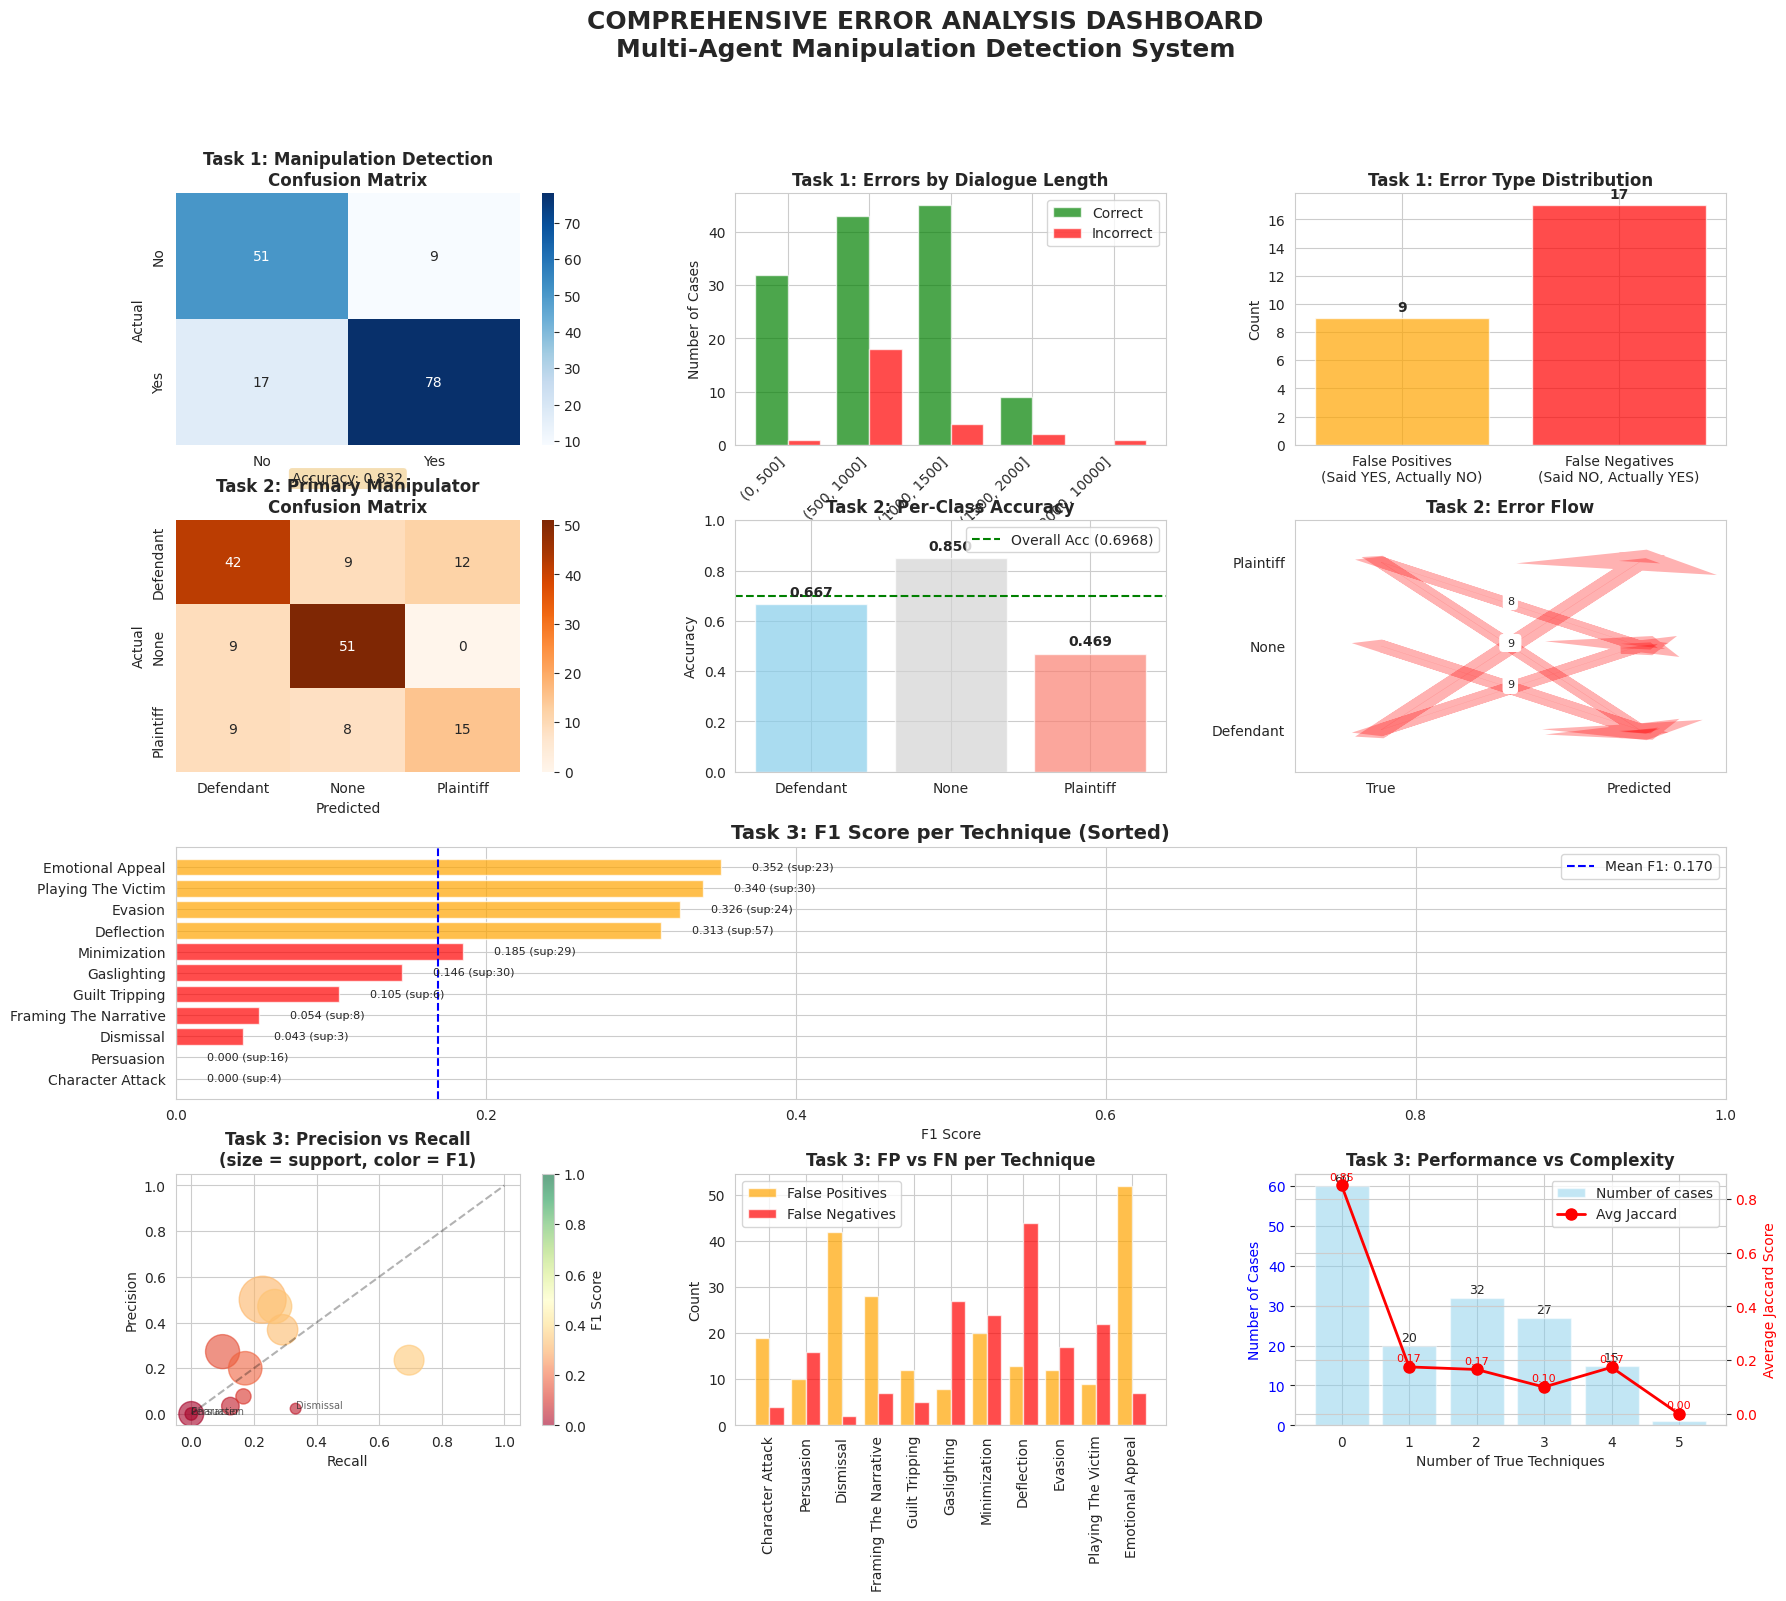


QUICK SUMMARY TABLE
          Task            Accuracy                                     Main Issue                        Recommended Fix
  1. Detection               0.832      17 False Negatives (missing manipulation)              Lower detection threshold
2. Manipulator               0.697 Plaintiff only 55.6% correct (class imbalance) Add Plaintiff examples + class weights
 3. Techniques 0.348 (exact match)                        Avg F1: 0.170 (too low)       Binary classifiers per technique


In [15]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (20, 12)

# Load data (same as before)
df = pd.read_csv('/kaggle/input/st1-stg2-p2/manipulation_results.csv')
df_test = pd.read_csv('/kaggle/input/data-clean2/test_split.csv')
test = pd.concat([df, df_test[['Manipulative', 'Primary Manipulator', 'Manipulation Techniques']]], axis=1)

# Parse techniques
def parse_techniques(x):
    if pd.isna(x) or x == "None" or x == "nan":
        return []
    return [t.strip().lower() for t in str(x).split(",") if t.strip() and t.strip().lower() != "none"]

test["true_techniques"] = test["Manipulation Techniques"].apply(parse_techniques)
test["pred_techniques"] = test["Techniques_Used"].apply(parse_techniques)
test["Manipulation_Present_bin"] = test["Manipulation_Present"].map({'Yes': 1, 'No': 0})
test["Manipulative_bin"] = test["Manipulative"].astype(int)
test["Primary_Manipulator"] = test["Primary_Manipulator"].fillna("None").str.strip()
test["Primary Manipulator"] = test["Primary Manipulator"].fillna("None").str.strip()
test['dialogue_length'] = test['Dialogue'].str.split().str.len()

# Create figure with subplots
fig = plt.figure(figsize=(20, 16))
gs = fig.add_gridspec(4, 3, hspace=0.3, wspace=0.3)

# ============================================================================
# TASK 1 VISUALIZATIONS
# ============================================================================

# 1. Task 1: Confusion Matrix
ax1 = fig.add_subplot(gs[0, 0])
from sklearn.metrics import confusion_matrix
cm1 = confusion_matrix(test["Manipulative_bin"], test["Manipulation_Present_bin"])
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues', ax=ax1, 
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
ax1.set_title('Task 1: Manipulation Detection\nConfusion Matrix', fontsize=12, fontweight='bold')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')

# Add accuracy in title
acc1 = (test["Manipulative_bin"] == test["Manipulation_Present_bin"]).mean()
ax1.text(0.5, -0.15, f'Accuracy: {acc1:.3f}', transform=ax1.transAxes, 
         ha='center', fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat'))

# 2. Task 1: Error distribution by dialogue length
ax2 = fig.add_subplot(gs[0, 1])
length_bins = [0, 500, 1000, 1500, 2000, 10000]
test['length_bin'] = pd.cut(test['dialogue_length'], bins=length_bins)

correct1 = test[test["Manipulative_bin"] == test["Manipulation_Present_bin"]].groupby('length_bin').size()
incorrect1 = test[test["Manipulative_bin"] != test["Manipulation_Present_bin"]].groupby('length_bin').size()

x_pos = np.arange(len(correct1))
ax2.bar(x_pos - 0.2, correct1.values, 0.4, label='Correct', color='green', alpha=0.7)
ax2.bar(x_pos + 0.2, incorrect1.values, 0.4, label='Incorrect', color='red', alpha=0.7)
ax2.set_xticks(x_pos)
ax2.set_xticklabels([str(b) for b in correct1.index], rotation=45, ha='right')
ax2.set_title('Task 1: Errors by Dialogue Length', fontsize=12, fontweight='bold')
ax2.set_xlabel('Dialogue Length (words)')
ax2.set_ylabel('Number of Cases')
ax2.legend()

# 3. Task 1: FP vs FN
ax3 = fig.add_subplot(gs[0, 2])
fp_count = len(test[(test["Manipulative_bin"] == 0) & (test["Manipulation_Present_bin"] == 1)])
fn_count = len(test[(test["Manipulative_bin"] == 1) & (test["Manipulation_Present_bin"] == 0)])
error_types = ['False Positives\n(Said YES, Actually NO)', 'False Negatives\n(Said NO, Actually YES)']
error_counts = [fp_count, fn_count]
colors = ['orange', 'red']
ax3.bar(error_types, error_counts, color=colors, alpha=0.7)
ax3.set_title('Task 1: Error Type Distribution', fontsize=12, fontweight='bold')
ax3.set_ylabel('Count')
for i, (label, count) in enumerate(zip(error_types, error_counts)):
    ax3.text(i, count + 0.5, str(count), ha='center', fontweight='bold')

# ============================================================================
# TASK 2 VISUALIZATIONS
# ============================================================================

# 4. Task 2: Confusion Matrix (3x3)
ax4 = fig.add_subplot(gs[1, 0])
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
all_labels = list(set(test["Primary Manipulator"].tolist() + test["Primary_Manipulator"].tolist()))
le.fit(all_labels)
y_true_enc = le.transform(test["Primary Manipulator"])
y_pred_enc = le.transform(test["Primary_Manipulator"])
cm2 = confusion_matrix(y_true_enc, y_pred_enc)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Oranges', ax=ax4,
            xticklabels=le.classes_, yticklabels=le.classes_)
ax4.set_title('Task 2: Primary Manipulator\nConfusion Matrix', fontsize=12, fontweight='bold')
ax4.set_xlabel('Predicted')
ax4.set_ylabel('Actual')

# 5. Task 2: Per-class accuracy
ax5 = fig.add_subplot(gs[1, 1])
class_accs = []
class_names = ['Defendant', 'None', 'Plaintiff']
for cls in class_names:
    subset = test[test["Primary Manipulator"] == cls]
    if len(subset) > 0:
        acc = (subset["Primary Manipulator"] == subset["Primary_Manipulator"]).mean()
        class_accs.append(acc)
    else:
        class_accs.append(0)

bars = ax5.bar(class_names, class_accs, color=['skyblue', 'lightgray', 'salmon'], alpha=0.7)
ax5.axhline(y=0.6968, color='green', linestyle='--', label='Overall Acc (0.6968)')
ax5.set_ylim(0, 1)
ax5.set_title('Task 2: Per-Class Accuracy', fontsize=12, fontweight='bold')
ax5.set_ylabel('Accuracy')
ax5.legend()

# Add values on bars
for i, (bar, acc) in enumerate(zip(bars, class_accs)):
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')

# 6. Task 2: Error flow (Sankey-style visualization)
ax6 = fig.add_subplot(gs[1, 2])
error_matrix = pd.DataFrame({
    'True': test["Primary Manipulator"],
    'Pred': test["Primary_Manipulator"]
})
errors_only = error_matrix[error_matrix['True'] != error_matrix['Pred']]
error_counts = errors_only.groupby(['True', 'Pred']).size().reset_index(name='count')

y_positions = {'Defendant': 0, 'None': 1, 'Plaintiff': 2}
for _, row in error_counts.iterrows():
    y_start = y_positions[row['True']]
    y_end = y_positions[row['Pred']]
    ax6.arrow(0.2, y_start, 0.6, y_end - y_start, 
              head_width=0.1, head_length=0.05, 
              fc='red', ec='red', alpha=0.3, linewidth=row['count'])
    ax6.text(0.5, (y_start + y_end)/2, str(row['count']), 
             ha='center', fontsize=8, bbox=dict(boxstyle='round', facecolor='white'))

ax6.set_xlim(0, 1)
ax6.set_ylim(-0.5, 2.5)
ax6.set_yticks([0, 1, 2])
ax6.set_yticklabels(['Defendant', 'None', 'Plaintiff'])
ax6.set_xticks([0.2, 0.8])
ax6.set_xticklabels(['True', 'Predicted'])
ax6.set_title('Task 2: Error Flow', fontsize=12, fontweight='bold')
ax6.grid(False)

# ============================================================================
# TASK 3 VISUALIZATIONS
# ============================================================================

# Calculate per-technique metrics
all_techniques = [
    'gaslighting', 'guilt tripping', 'emotional appeal',
    'character attack', 'deflection', 'framing the narrative',
    'minimization', 'evasion', 'dismissal',
    'playing the victim', 'persuasion'
]

tech_metrics = []
for tech in all_techniques:
    y_true = test["true_techniques"].apply(lambda x: tech in x)
    y_pred = test["pred_techniques"].apply(lambda x: tech in x)
    
    tp = sum(y_true & y_pred)
    fp = sum(~y_true & y_pred)
    fn = sum(y_true & ~y_pred)
    
    support = sum(y_true)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    tech_metrics.append({
        'technique': tech.replace('_', ' ').title(),
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'support': support,
        'fp': fp,
        'fn': fn
    })

tech_df = pd.DataFrame(tech_metrics).sort_values('f1')

# 7. Task 3: F1 scores per technique
ax7 = fig.add_subplot(gs[2, :])
colors_tech = ['red' if f1 < 0.2 else 'orange' if f1 < 0.4 else 'green' 
               for f1 in tech_df['f1']]
bars = ax7.barh(tech_df['technique'], tech_df['f1'], color=colors_tech, alpha=0.7)
ax7.axvline(x=tech_df['f1'].mean(), color='blue', linestyle='--', 
            label=f'Mean F1: {tech_df["f1"].mean():.3f}')
ax7.set_xlabel('F1 Score')
ax7.set_title('Task 3: F1 Score per Technique (Sorted)', fontsize=14, fontweight='bold')
ax7.set_xlim(0, 1)
ax7.legend()

# Add values
for i, (bar, row) in enumerate(zip(bars, tech_df.itertuples())):
    width = bar.get_width()
    ax7.text(width + 0.02, bar.get_y() + bar.get_height()/2.,
             f'{row.f1:.3f} (sup:{row.support})', 
             ha='left', va='center', fontsize=8)

# 8. Task 3: Precision vs Recall scatter
ax8 = fig.add_subplot(gs[3, 0])
scatter = ax8.scatter(tech_df['recall'], tech_df['precision'], 
                     s=tech_df['support']*20, alpha=0.6, c=tech_df['f1'],
                     cmap='RdYlGn', vmin=0, vmax=1)
ax8.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax8.set_xlabel('Recall')
ax8.set_ylabel('Precision')
ax8.set_title('Task 3: Precision vs Recall\n(size = support, color = F1)', 
              fontsize=12, fontweight='bold')
ax8.set_xlim(-0.05, 1.05)
ax8.set_ylim(-0.05, 1.05)
plt.colorbar(scatter, ax=ax8, label='F1 Score')

# Add labels for worst performers
worst_3 = tech_df.nsmallest(3, 'f1')
for _, row in worst_3.iterrows():
    ax8.annotate(row['technique'][:10], 
                (row['recall'], row['precision']),
                fontsize=7, alpha=0.7)

# 9. Task 3: False Positives vs False Negatives
ax9 = fig.add_subplot(gs[3, 1])
x_pos = np.arange(len(tech_df))
ax9.bar(x_pos - 0.2, tech_df['fp'].values, 0.4, label='False Positives', color='orange', alpha=0.7)
ax9.bar(x_pos + 0.2, tech_df['fn'].values, 0.4, label='False Negatives', color='red', alpha=0.7)
ax9.set_xticks(x_pos)
ax9.set_xticklabels(tech_df['technique'], rotation=90)
ax9.set_title('Task 3: FP vs FN per Technique', fontsize=12, fontweight='bold')
ax9.set_ylabel('Count')
ax9.legend()

# 10. Task 3: Technique count distribution
ax10 = fig.add_subplot(gs[3, 2])
test['num_true_techniques'] = test['true_techniques'].apply(len)
test['num_pred_techniques'] = test['pred_techniques'].apply(len)

# Jaccard by number of techniques
jaccard_by_count = []
for n in range(0, 6):
    subset = test[test['num_true_techniques'] == n]
    if len(subset) > 0:
        jaccards = []
        for idx, row in subset.iterrows():
            true_set = set(row['true_techniques'])
            pred_set = set(row['pred_techniques'])
            if len(true_set | pred_set) > 0:
                j = len(true_set & pred_set) / len(true_set | pred_set)
            else:
                j = 1.0
            jaccards.append(j)
        jaccard_by_count.append((n, len(subset), np.mean(jaccards)))

counts, sizes, jaccards = zip(*jaccard_by_count)
ax10_twin = ax10.twinx()

bars = ax10.bar(counts, sizes, alpha=0.5, color='skyblue', label='Number of cases')
line = ax10_twin.plot(counts, jaccards, 'ro-', linewidth=2, markersize=8, label='Avg Jaccard')

ax10.set_xlabel('Number of True Techniques')
ax10.set_ylabel('Number of Cases', color='blue')
ax10_twin.set_ylabel('Average Jaccard Score', color='red')
ax10.set_title('Task 3: Performance vs Complexity', fontsize=12, fontweight='bold')
ax10.tick_params(axis='y', labelcolor='blue')
ax10_twin.tick_params(axis='y', labelcolor='red')

# Add values on bars
for i, (count, size, jacc) in enumerate(jaccard_by_count):
    ax10.text(count, size + 1, str(size), ha='center', fontsize=9)
    ax10_twin.text(count, jacc + 0.02, f'{jacc:.2f}', ha='center', fontsize=8, color='red')

# Combine legends
lines1, labels1 = ax10.get_legend_handles_labels()
lines2, labels2 = ax10_twin.get_legend_handles_labels()
ax10.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

# Overall title
fig.suptitle('COMPREHENSIVE ERROR ANALYSIS DASHBOARD\nMulti-Agent Manipulation Detection System', 
             fontsize=18, fontweight='bold', y=0.995)

plt.tight_layout()
plt.savefig('error_analysis_dashboard.png', dpi=300, bbox_inches='tight')
print("✅ Dashboard saved to 'error_analysis_dashboard.png'")
plt.show()

# ============================================================================
# SUMMARY STATISTICS TABLE
# ============================================================================
print("\n" + "="*100)
print("QUICK SUMMARY TABLE")
print("="*100)

summary_data = {
    'Task': ['1. Detection', '2. Manipulator', '3. Techniques'],
    'Accuracy': [
        f"{(test['Manipulative_bin'] == test['Manipulation_Present_bin']).mean():.3f}",
        f"{(test['Primary Manipulator'] == test['Primary_Manipulator']).mean():.3f}",
        f"0.348 (exact match)"
    ],
    'Main Issue': [
        f"{fn_count} False Negatives (missing manipulation)",
        f"Plaintiff only 55.6% correct (class imbalance)",
        f"Avg F1: {tech_df['f1'].mean():.3f} (too low)"
    ],
    'Recommended Fix': [
        "Lower detection threshold",
        "Add Plaintiff examples + class weights",
        "Binary classifiers per technique"
    ]
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))
print("="*100)